In [1]:
'''
Authors: Jieyu Lu, Charlotte Infante, Song Xia
This notebook would not be possible without Jieyu Lu's contribution to this code
https://github.com/HelloJocelynLu/t5chem
https://github.com/HelloJocelynLu/EFGs
Thank You
'''
from rdkit import Chem
import re
import numpy as np
import shap
import torch
#from EFGs import mol2frag
#from matplotlib import cm
from IPython.display import SVG, Image
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from t5chem import SimpleTokenizer, T5ForProperty
from transformers import T5ForConditionalGeneration
from tqdm import tqdm
import os 
import joblib
import pdb

In [63]:
def prettymol(smiles, shap_value,all_IDs, asMol=False, label=None, path='', imgsize=(300, 200), highlights=None):
    '''
    highlights is a dictionary, which may contain:
    highlightAtoms: list
    highlightBonds: list
    highlightAtomRadii: dict[int]=float, atom index (int), radius (float)
    highlightAtomColors: dict[int]=tuple, index (int), color (tuple, length=3)
    highlightBondColors: dict[int]=tuple,index (int), color (tuple, length=3)
    '''
    if asMol:
        mol = smiles.__copy__()
    else:
        mol = Chem.MolFromSmiles(smiles)
    mol = rdMolDraw2D.PrepareMolForDrawing(mol)
    if '.png' in path:
        drawer = rdMolDraw2D.MolDraw2DCairo(*imgsize)
    else:
        drawer = rdMolDraw2D.MolDraw2DSVG(*imgsize)
    opts = drawer.drawOptions()
    
    y = 0 
    # get the first idx of each functional group tuple
    first_atom_in_func_group = [t[0] for t in all_IDs]
    # link the first idx of each func group to each func group value and sort them from least to greatest
    paired_values = sorted(zip(shap_value, first_atom_in_func_group), key=lambda x: x[1])
    # get only the shap values from paired_values
    shap_value_organized = [t[0] for t in paired_values]
    # get the organized 0 to greatest first atom and make a list 
    first_atom_in_func_group = [t[1] for t in paired_values]
    
    if label == 'map':
        for i in range(mol.GetNumAtoms()):
            opts.atomLabels[i] = mol.GetAtomWithIdx(
                i).GetSymbol()+str(mol.GetAtomWithIdx(i).GetAtomMapNum())
    elif label == 'idx':
        for i in range(mol.GetNumAtoms()):
            opts.atomLabels[i] = mol.GetAtomWithIdx(i).GetSymbol()+str(i)
    else:
        _ = [a.ClearProp('molAtomMapNumber') for a in mol.GetAtoms()]
        for i in range(len(mol.GetAtoms())):
            atom = mol.GetAtomWithIdx(i)
            if y < len(first_atom_in_func_group) and i == first_atom_in_func_group[y]:
                atom.SetProp('atomNote', str(round(shap_value_organized[y],2)))
                print(round(shap_value_organized[y],2))
                y += 1
                
            else:
                atom.SetProp('atomNote', '')
    if not highlights:
        drawer.DrawMolecule(mol)
    else:
        drawer.DrawMolecule(mol, **highlights)
    drawer.FinishDrawing()
    if '.png' in path:
        drawer.WriteDrawingText(path)
        display(Image(path))
    else:
        svg = drawer.GetDrawingText()
        display(SVG(svg.replace('svg:','')))
        if '.svg' in path:
            with open(path, 'w') as wf:
                print(svg, file=wf)
    return drawer


def classifier(x):
    x = [ i for i in x]
    #remove spaces made between each character 
    x = [s.replace(" " , "") for s in x]
    tv = tokenizer.batch_encode_plus(x, return_tensors='pt', truncation=True, padding="max_length", max_length=500)
    if 'token_type_ids' in tv:
        del tv['token_type_ids']
    for k,v in tv.items():
        if isinstance(v, torch.Tensor):
            tv[k] = v.to(device)
    outputs = model(**tv).logits.detach().cpu().numpy()
    breakpoint()
    data_dir = '/scratch/cii2002/pka/NEW_TRAINING_DATA/REGRESSION/MICRO/prot2deprot_with_pairs/EXP/RANDOM_ENSEMBLE/1/'
    scaler = joblib.load(os.path.join(data_dir, 'MinMaxScaler.gz'))
    outputs_unscaled = scaler.inverse_transform(outputs)
    return outputs_unscaled
    
def analysis(shap_value, molecule):
    '''prints out base value, sum of shap values, prediction from SHAP based on addition of base value and
    sum of shap values, and prediction from classifier function'''
    sum_array = shap_value.values.sum()
    sum_shap_base_value = sum_array + shap_values.base_values
    predictions = classifier([molecule])
    print("base value", shap_values.base_values)
    print("sum of SHAP",sum_array)
    print("SHAP pred", sum_shap_base_value)
    print("prediction from classifier", predictions)
    print('')

In [65]:
# load the model and tokenizer
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
tokenizer = SimpleTokenizer(vocab_file='/scratch/cii2002/t5chem_new/t5chem_pKa/model_PKA/vocab.pt')
model = T5ForProperty.from_pretrained('/scratch/cii2002/t5chem_new/t5chem_pKa/model_PKA').to(device)
model.config.task_specific_params = {}
# define the input sentences we want to translate
data = [
    "CC(=O)>>CC(=O)", #Regression
]


In [66]:
#masker = shap.maskers.Text(tokenizer, mask_token = "<pad>")
masker = shap.maskers.Text(tokenizer, mask_token=tokenizer.mask_token)
explainer = shap.Explainer(classifier, masker, output_names=['Property']) 
shap_values = explainer(data)  

shap.plots.text(shap_values)

Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use a

  0%|          | 0/182 [00:00<?, ?it/s]

Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use a

IndexError: index 1 is out of bounds for axis 0 with size 1

In [81]:
torch.cuda.get_arch_list()

[]

In [82]:
print(torch.__version__)

1.7.1


In [83]:
analysis(shap_values, "acidic:CC(=O)c1ccccc1")

base value [[7.70202065]]
sum of SHAP 3.453768730163574
SHAP pred [[11.15578938]]
prediction from classifier [[11.155789]]



Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.


C=O [ 1.50275177 -0.62643537 -0.76855136 -0.16655663  0.28724857] 0.22845697402954102
c1ccccc1 [-0.08307406 -0.34034038 -0.21333221 -0.20618272 -0.20864247 -0.12441938
 -0.22014458 -0.99438669] -2.3905224800109863
C010 [0.5406476] 0.5406475961208344
0.54
0.23
-2.39


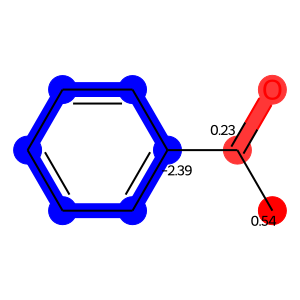

In [91]:
import matplotlib
from matplotlib.colors import Normalize
def map_atom2stridx(smiles):
    pattern = "[=#]?(\[[^\]]+\]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p)[0-9]{0,2}"
    atom_finder = re.compile(pattern)
    ms = [x for x in atom_finder.finditer(smiles)]
    map_dict = {i:(x.start(),x.end()) for i,x in enumerate(ms)}
    smiles = smiles.replace('>>', '.') if '>>' in smiles else smiles.replace('>', '.')
    assert Chem.MolFromSmiles(smiles).GetNumAtoms() == len(map_dict)
    return map_dict
def token2fg(fgids, map_dict):
    from itertools import chain
    fg_dict = {}
    for i,fg in enumerate(fgids):
        for a in fg:
            fg_dict[i] = list(chain(fg_dict.get(i,[]), range(map_dict[a][0],map_dict[a][1])))
    return fg_dict
def smiles2fgid(smiles):
    '''
    Groups the SMILES string into functional groups.
    Input:
        SMILES string
    Returns:
        token2fg(fg_id+fgch_id, map_dict)
            Type: dictionary
            Key is within range of 0 to length of number of functional groups found.
            For each Key, is a list with the atom index of each atom in functional group 
        fg+chs
            Type: list 
            List of strings; a string representation of each functional group
        fg_id+fgch_id
            Type: list 
            List of tuples; containing each atom index in each functional group grouped by tuples
    example:
        fg_dict, all_fgs, all_ids = smiles2fgid('NC(Cc1cnc[nH]1)C(=O)O')
            
    '''
    map_dict = map_atom2stridx(smiles)
    mol = Chem.MolFromSmiles(smiles.replace('>>', '.') if '>>' in smiles else smiles.replace('>', '.'))
    fg, chs, fg_id, fgch_id = mol2frag(mol, returnidx=True, TreatHs='include')
    return token2fg(fg_id+fgch_id, map_dict), fg+chs, fg_id+fgch_id

# Skip prefix; not needed to draw molecule
smiles = data[0].split(':', 1)[-1].strip()

# group functional groups together 
fg_dict, all_fgs, all_ids = smiles2fgid(smiles)

# get mol from smiles 
mol = Chem.MolFromSmiles(smiles)
# get shap values into an array
shap_tokens = np.array([shap_values.values[0][i][0] for i in range(1,len(smiles)+1)])
# get color map 
bwr = matplotlib.colormaps.get_cmap('bwr')
# get the SHAP value for each functional group 
func_group_value = [np.sum(shap_tokens[fg_dict[i]]) for i,fg in enumerate(all_ids)]
# get all SHAP values
values = [shap_values.values[0][i][0] for i in range(len(smiles))]
# Normalize colors based on the min and max value of each functional group 
my_norm = Normalize(vmin=min(func_group_value), vmax=max(func_group_value)) 


color_dicts_a = {}
color_dicts_b = {}

# include the shap values from parenthesis
for i,fg in enumerate(all_ids):
    if all_fgs[i] == 'O':
        fg_dict[i].append(fg_dict[i][0] + 1)
        fg_dict[i].append(fg_dict[i][0] - 1)
    if all_fgs[i] == '[NH3+]' and smiles[fg_dict[i][0] -1] == '(':
        first_value = fg_dict[i][0] # [
        last_value = fg_dict[i][-1] # ]
        fg_dict[i].append(first_value - 1)
        fg_dict[i].append(last_value + 1)
    if all_fgs[i] == 'O=CO' and smiles[fg_dict[i][-1]+1] == ')':
        atom_of_interest = fg_dict[i][-1] #(O)
        fg_dict[i].append(atom_of_interest - 1)
        fg_dict[i].append(atom_of_interest + 1)
    if all_fgs[i] == 'NC=O' and smiles[fg_dict[i][-1]+1] == ')':
        oxygen = fg_dict[i][-1] # O)
        d_bond = fg_dict[i][-1] -1 # =
        fg_dict[i].append(d_bond - 1)
        fg_dict[i].append(oxygen + 1)
    if all_fgs[i] == 'C=O' and smiles[fg_dict[i][-1]+1] == ')':
        oxygen = fg_dict[i][-1] # O)
        d_bond = fg_dict[i][-1] -1 # =
        fg_dict[i].append(d_bond - 1)
        fg_dict[i].append(oxygen + 1)
        
# get the SHAP value for each functional group 
func_group_value = [np.sum(shap_tokens[fg_dict[i]]) for i,fg in enumerate(all_ids)]
# Normalize colors based on the min and max value of each functional group 
my_norm = Normalize(vmin=min(func_group_value), vmax=max(func_group_value)) 
#my_norm = Normalize(-10, 10) 
#my_norm = Normalize(vmin=min(values), vmax=max(values))


for i,fg in enumerate(all_ids):
    shap_val = shap_tokens[fg_dict[i]]
    print(all_fgs[i], shap_val, np.sum(shap_val))
    for a in fg:
        color_dicts_a[a] = bwr(my_norm(np.sum(shap_val)))
        

    
for bond in mol.GetBonds():
    a = bond.GetBeginAtom().GetIdx()
    b = bond.GetEndAtom().GetIdx()
    if a in color_dicts_a and b in color_dicts_a and color_dicts_a[a]==color_dicts_a[b]:
        color_dicts_b[bond.GetIdx()] = color_dicts_a[a]
prettymol(mol, func_group_value, all_ids,asMol=True, highlights={'highlightAtoms':color_dicts_a.keys(), 'highlightAtomColors':color_dicts_a, 'highlightBonds':color_dicts_b.keys(),'highlightBondColors':color_dicts_b}, imgsize=(300,300), path="shap.svg")
 

In [87]:
smiles = data[0].split(':', 1)[-1].strip()
mols = [shap_values.data[0][i] for i in range(len(smiles))]
values = [shap_values.values[0][i][0] for i in range(len(smiles))]

In [88]:
values

[5.075186640024185,
 0.5406475961208344,
 1.5027517676353455,
 -0.16655662655830383,
 -0.6264353692531586,
 -0.7685513645410538,
 0.28724856674671173,
 -0.08307406306266785,
 -0.34034037590026855,
 -0.21333220601081848,
 -0.20618271827697754,
 -0.20864246785640717,
 -0.12441937625408173,
 -0.220144584774971]

In [89]:
import pandas as pd
df = pd.DataFrame({'atom or prefix': mols, 'value': values})

In [90]:
df

,atom or prefix,value
0,acidic:,5.075187
1,C,0.540648
2,C,1.502752
3,(,-0.166557
4,=,-0.626435
5,O,-0.768551
6,),0.287249
7,c,-0.083074
8,1,-0.340340
9,c,-0.213332
